In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# loading the data files 

credit = pd.read_excel(r"CreditConsumptionData.xlsx")
customer = pd.read_excel(r"CustomerBehaviorData.xlsx")
demography = pd.read_excel(r"CustomerDemographics.xlsx")

#print the result 
credit.head()

,ID,cc_cons
0,17051,16239.0
1,11491,39002.0
2,7433,21182.0
3,14606,8123.0
4,8381,28282.0


In [3]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       20000 non-null  int64  
 1   cc_cons  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 312.6 KB


In [4]:
customer.head()
print(len(customer))

20000


In [5]:
customer.isnull().sum()

ID                       0
cc_cons_apr              0
dc_cons_apr              0
cc_cons_may              1
dc_cons_may              1
cc_cons_jun              0
dc_cons_jun              1
cc_count_apr             1
cc_count_may             0
cc_count_jun             0
dc_count_apr             0
dc_count_may             0
dc_count_jun             0
card_lim                 0
personal_loan_active     0
vehicle_loan_active      0
personal_loan_closed     1
vehicle_loan_closed      0
investment_1             0
investment_2             0
investment_3             2
investment_4             0
debit_amount_apr         0
credit_amount_apr        0
debit_count_apr          1
credit_count_apr         0
max_credit_amount_apr    0
debit_amount_may         0
credit_amount_may        0
credit_count_may         0
debit_count_may          0
max_credit_amount_may    0
debit_amount_jun         0
credit_amount_jun        0
credit_count_jun         0
debit_count_jun          0
max_credit_amount_jun    0
l

In [6]:
demography.head()

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
0,17051,current,M,30,MEDIUM,26.4,9,9,355,0
1,11491,current,M,37,LOW,14.4,7,7,485,0
2,7433,current,M,33,MEDIUM,3.2,1,1,764,0
3,14606,current,M,63,LOW,10.2,6,6,863,0
4,8381,saving,M,33,MEDIUM,26.4,6,6,523,0


In [7]:
demography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  20000 non-null  object 
 2   gender                        20000 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        20000 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   20000 non-null  int64  
 8   NetBanking_Flag               20000 non-null  int64  
 9   Avg_days_between_transaction  20000 non-null  int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 1.5+ MB


In [8]:
f1= customer.merge(demography , on = "ID" , how = 'left')
final = f1.merge(credit , on = "ID" , how = 'left')
final.head()

,ID,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,...,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,cc_cons
0,17051,2017.46,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,35,...,current,M,30,MEDIUM,26.4,9,9,355,0,16239.0
1,11491,7687.00,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,50,...,current,M,37,LOW,14.4,7,7,485,0,39002.0
2,7433,9094.46,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,47,...,current,M,33,MEDIUM,3.2,1,1,764,0,21182.0
3,14606,3126.00,4616.33,8676.80,5923.00,6717.000,18747.00,4.0,30,1,...,current,M,63,LOW,10.2,6,6,863,0,8123.0
4,8381,24988.72,10091.23,10132.00,3477.00,4667.000,511.00,2.0,8,5,...,saving,M,33,MEDIUM,26.4,6,6,523,0,28282.0


In [9]:
final.columns

Index(['ID', 'cc_cons_apr', 'dc_cons_apr', 'cc_cons_may', 'dc_cons_may',
       'cc_cons_jun', 'dc_cons_jun', 'cc_count_apr', 'cc_count_may',
       'cc_count_jun', 'dc_count_apr', 'dc_count_may', 'dc_count_jun',
       'card_lim', 'personal_loan_active', 'vehicle_loan_active',
       'personal_loan_closed', 'vehicle_loan_closed', 'investment_1',
       'investment_2', 'investment_3', 'investment_4', 'debit_amount_apr',
       'credit_amount_apr', 'debit_count_apr', 'credit_count_apr',
       'max_credit_amount_apr', 'debit_amount_may', 'credit_amount_may',
       'credit_count_may', 'debit_count_may', 'max_credit_amount_may',
       'debit_amount_jun', 'credit_amount_jun', 'credit_count_jun',
       'debit_count_jun', 'max_credit_amount_jun', 'loan_enq', 'emi_active',
       'account_type', 'gender', 'age', 'Income', 'Emp_Tenure_Years',
       'Tenure_with_Bank', 'region_code', 'NetBanking_Flag',
       'Avg_days_between_transaction', 'cc_cons'],
      dtype='object')

In [10]:
from sklearn.preprocessing import OrdinalEncoder

In [11]:
# sklearn library importation 

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# accuracy check 
from sklearn.metrics import mean_squared_error, r2_score # Regression ke liye
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Classification ke liye

#for train_test model
from sklearn.model_selection import train_test_split

#for linear number trening 
from sklearn.linear_model    import LinearRegression , LogisticRegression
from sklearn.ensemble import RandomForestRegressor , RandomForestClassifier

from sklearn.svm import SVC


In [12]:
X = final.drop('cc_cons', axis=1)
y = final['cc_cons']

In [13]:
cat_cols = X.select_dtypes(include='object').columns

In [14]:
# checking for the type of the dataframe 

for col in cat_cols:
    print(col, X[col].apply(type).unique())

loan_enq [<class 'str'> <class 'float'>]
account_type [<class 'str'> <class 'int'>]
gender [<class 'str'> <class 'int'>]
Income [<class 'str'> <class 'int'>]


In [15]:
#  convert all the data in to str only 

X[cat_cols] = X[cat_cols].astype(str)
X[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   loan_enq      20000 non-null  object
 1   account_type  20000 non-null  object
 2   gender        20000 non-null  object
 3   Income        20000 non-null  object
dtypes: object(4)
memory usage: 625.1+ KB


In [16]:
# encodering part
encoder = OneHotEncoder(drop='first' )
X_encoded = encoder.fit_transform(X[cat_cols])

In [17]:
encoded_df = pd.DataFrame(X_encoded)

In [18]:
num_cols = X.select_dtypes(exclude='object').columns

In [19]:
X_new = pd.concat([X[num_cols].reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)


In [20]:
X_train, X_test , y_train , y_test = train_test_split(X_new ,y, test_size=0.2 , random_state = 2)

In [21]:
# Sabhi column names ko string mein convert karein
X_new.columns = X_new.columns.astype(str)

#final code in one cell only 

In [22]:
# Split
train = final[final['cc_cons'].notnull()]
test  = final[final['cc_cons'].isnull()]

X = train.drop('cc_cons', axis=1)
y = train['cc_cons']

# Categorical columns
cat_cols = X.select_dtypes(include='object').columns

# Clean
X[cat_cols] = X[cat_cols].astype(str)

# Encode
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = encoder.fit_transform(X[cat_cols])

encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Combine
num_cols = X.select_dtypes(exclude='object').columns

X_final = pd.concat(
    [X[num_cols].reset_index(drop=True), encoded_df.reset_index(drop=True)],
    axis=1
)

# Model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_final, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
from sklearn.model_selection import train_test_split   
from sklearn.metrics import mean_squared_error, r2_score

# X_final ko train aur validation mein split karein
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Model ko sirf X_train par fit karein
model.fit(X_train, y_train)

# Validation set par predict karein
y_val_pred = model.predict(X_val)

# Performance check karein
print(f"R2 Score: {r2_score(y_val, y_val_pred)}")
print(f"RMSE: {mean_squared_error(y_val, y_val_pred)**0.5}")

R2 Score: 0.8362390627199499
RMSE: 2867.9476468016965


In [24]:
#fine tuning model 

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor  # Import RandomForestRegressor

# Define param_grid before using it
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Now use the defined param_grid
random_search = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_distributions = param_grid,  # Now param_grid is defined
    n_iter = 20,      # Sirf 20 random combinations check karega (Isse time kam lagega)
    cv = 3,           # CV ko 5 se 3 kar dein fast result ke liye
    scoring = 'r2',
    n_jobs = -1,
    verbose = 2,
    random_state = 42  
)

random_search.fit(X_final, y)

print(f"Best Params: {random_search.best_params_}")
print(f"Best R²: {random_search.best_score_:.4f}")
best_model = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
9 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    va

Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best R²: 0.6871


In [ ]:
#feature importance 

                  feature  importance
1             cc_cons_apr    0.196716
3             cc_cons_may    0.196126
5             cc_cons_jun    0.103616
4             dc_cons_may    0.090070
2             dc_cons_apr    0.068388
37             emi_active    0.014361
31  max_credit_amount_may    0.013266
23      credit_amount_apr    0.011912
42        NetBanking_Flag    0.011673
22       debit_amount_apr    0.011652
26  max_credit_amount_apr    0.011627
28      credit_amount_may    0.011498
13               card_lim    0.011483
6             dc_cons_jun    0.011433
36  max_credit_amount_jun    0.011382


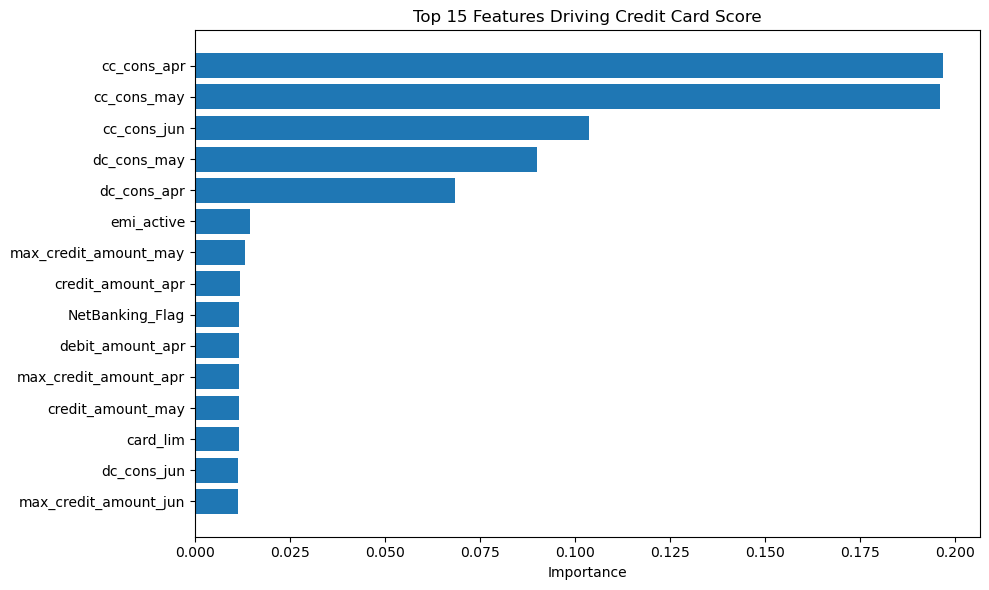

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature'   : X_final.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Features Driving Credit Card Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#predict on set 

In [32]:
# Apply same encoding to test set
test_features = test.drop('cc_cons', axis=1)
test_features[cat_cols] = test_features[cat_cols].astype(str)

In [35]:
# Encoding logic with unknown category handling
for col in cat_cols:
    # Pandas Index mein column ki numerical position find karne ke liye get_loc use karein
    col_idx = cat_cols.get_loc(col) 
    
    # Encoder se training ke time seekhi gayi categories nikalein
    known_categories = encoder.categories_[col_idx]
    
    # Test data mein check karein agar koi aisi category hai jo training mein nahi thi
    mask = ~test_features[col].isin(known_categories)
    
    # Agar unknown category milti hai, toh use pehli known category se replace karein
    if mask.any():
        test_features.loc[mask, col] = known_categories[0]
        print(f"Replaced {mask.sum()} unknown values in column '{col}'")

# Final transformation
test_encoded = encoder.transform(test_features[cat_cols])
print("Transformation successful!")

Transformation successful!


In [36]:

# Encode test using the SAME encoder (no re-fit)
test_encoded = encoder.transform(test_features[cat_cols])
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(cat_cols))

test_final = pd.concat(
    [test_features[num_cols].reset_index(drop=True), test_encoded_df.reset_index(drop=True)],
    axis=1
)

# Predict
test['cc_cons_predicted'] = best_model.predict(test_final)

# Export
test[['cc_cons_predicted']].to_csv('credit_score_predictions.csv', index=False)
print("Predictions saved!")

Predictions saved!


C:\Users\nobroker\AppData\Local\Temp\ipykernel_9164\3447704902.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['cc_cons_predicted'] = best_model.predict(test_final)


In [34]:
# Apply same encoding to test set
test_features = test.drop('cc_cons', axis=1)
test_features[cat_cols] = test_features[cat_cols].astype(str)

# Handle unknown categories by replacing them with a known category or most frequent value
for col in cat_cols:
    # Get the categories that the encoder knows about for this column
    known_categories = encoder.categories_[cat_cols.index(col)]
    
    # Replace unknown categories with the most frequent category from training
    # or you can use a default value like 'Unknown'
    mask = ~test_features[col].isin(known_categories)
    if mask.any():
        # Replace unknown values with the first known category (you can change this logic)
        test_features.loc[mask, col] = known_categories[0]
        print(f"Replaced {mask.sum()} unknown values in column '{col}'")

# Encode test using the SAME encoder (no re-fit)
test_encoded = encoder.transform(test_features[cat_cols])
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(cat_cols))

test_final = pd.concat(
    [test_features[num_cols].reset_index(drop=True), test_encoded_df.reset_index(drop=True)],
    axis=1
)

# Predict
test['cc_cons_predicted'] = best_model.predict(test_final)

# Export
test[['cc_cons_predicted']].to_csv('credit_score_predictions.csv', index=False)
print("Predictions saved!")

Replaced 1 unknown values in column 'account_type'
Replaced 1 unknown values in column 'gender'
Replaced 1 unknown values in column 'Income'
Transformation successful!


In [ ]:
#saving 

In [37]:
import joblib

joblib.dump(best_model, 'credit_score_model.pkl')
joblib.dump(encoder,    'encoder.pkl')
print("Model and encoder saved!")

Model and encoder saved!
